In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [2]:
PROJECT_ROOT = Path.cwd().parent

BASELINE_RESULTS_DIR = PROJECT_ROOT / "results" / "baseline"
LORA_RESULTS_DIR = PROJECT_ROOT / "results" / "lora"

BASELINE_CKPT_DIR = PROJECT_ROOT / "checkpoints" / "baseline"
LORA_CKPT_DIR = PROJECT_ROOT / "checkpoints" / "lora"

In [3]:
baseline_exp = "mhubert_base_swa_10min"
lora_exp = "mhubert_lora_swa_10min_r8"

baseline_history_path = BASELINE_RESULTS_DIR / f"{baseline_exp}_history.json"
lora_history_path = LORA_RESULTS_DIR / f"{lora_exp}_history.json"

baseline_ckpt_path = BASELINE_CKPT_DIR / f"{baseline_exp}_best.pt"
lora_ckpt_path = LORA_CKPT_DIR / f"{lora_exp}_best.pt"

In [14]:
baseline_results_path = BASELINE_RESULTS_DIR / f"{baseline_exp}_results.json"
lora_results_path = LORA_RESULTS_DIR / f"{lora_exp}_results.json"

with open(baseline_results_path, "r") as f:
    baseline_results = json.load(f)

with open(lora_results_path, "r") as f:
    lora_results = json.load(f)

print("Baseline results")
print("----------------")
print(f"CER: {baseline_results['cer']:.2%}")
print(f"Best dev loss: {baseline_results['best_dev_loss']:.4f}")
print(f"Training time: {baseline_results['training_time_minutes']:.1f} minutes")

print()

print("LoRA results")
print("------------")
print(f"CER: {lora_results['cer']:.2%}")
print(f"Best dev loss: {lora_results['best_dev_loss']:.4f}")
print(f"Training time: {lora_results['training_time_minutes']:.1f} minutes")

Baseline results
----------------
CER: 28.69%
Best dev loss: 1.3814
Training time: 25.0 minutes

LoRA results
------------
CER: 18.49%
Best dev loss: 0.9237
Training time: 26.2 minutes


In [4]:
with open(baseline_history_path, "r", encoding="utf-8") as f:
    baseline_history = json.load(f)

with open(lora_history_path, "r", encoding="utf-8") as f:
    lora_history = json.load(f)

baseline_train_loss = baseline_history["train_loss"]
baseline_dev_loss = baseline_history["dev_loss"]
baseline_epochs = np.arange(1, len(baseline_train_loss) + 1)

lora_train_loss = lora_history["train_loss"]
lora_dev_loss = lora_history["dev_loss"]
lora_epochs = np.arange(1, len(lora_train_loss) + 1)

In [5]:
baseline_ckpt = torch.load(baseline_ckpt_path, map_location="cpu")
lora_ckpt = torch.load(lora_ckpt_path, map_location="cpu")

baseline_best_epoch = baseline_ckpt["epoch"] + 1
baseline_best_loss = baseline_ckpt["dev_loss"]

lora_best_epoch = lora_ckpt["epoch"] + 1
lora_best_loss = lora_ckpt["dev_loss"]

print("Baseline best epoch:", baseline_best_epoch, "| best dev loss:", baseline_best_loss)
print("LoRA best epoch:", lora_best_epoch, "| best dev loss:", lora_best_loss)

Baseline best epoch: 55 | best dev loss: 1.3814455775114207
LoRA best epoch: 80 | best dev loss: 0.9236888656249413


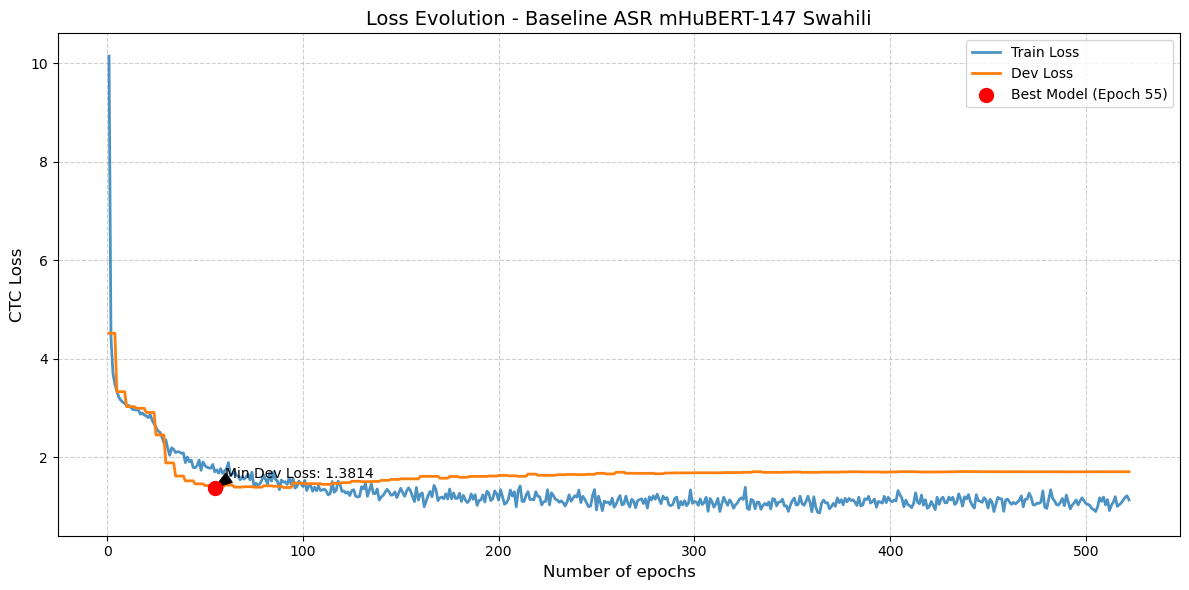

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(baseline_epochs, baseline_train_loss, label="Train Loss", lw=2, alpha=0.8)
plt.plot(baseline_epochs, baseline_dev_loss, label="Dev Loss", lw=2)

plt.scatter(
    baseline_best_epoch,
    baseline_best_loss,
    color="red",
    s=100,
    zorder=5,
    label=f"Best Model (Epoch {baseline_best_epoch})",
)

plt.annotate(
    f"Min Dev Loss: {baseline_best_loss:.4f}",
    xy=(baseline_best_epoch, baseline_best_loss),
    xytext=(baseline_best_epoch + 5, baseline_best_loss + 0.2),
    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=8),
)

plt.title("Loss Evolution - Baseline ASR mHuBERT-147 Swahili", fontsize=14)
plt.xlabel("Number of epochs", fontsize=12)
plt.ylabel("CTC Loss", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

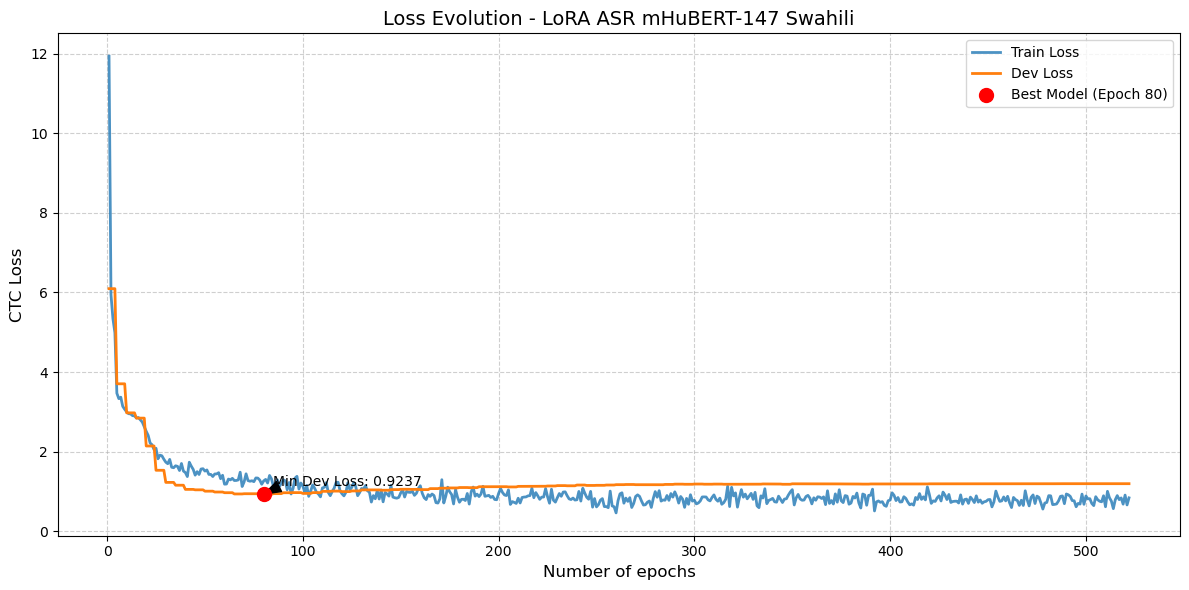

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(lora_epochs, lora_train_loss, label="Train Loss", lw=2, alpha=0.8)
plt.plot(lora_epochs, lora_dev_loss, label="Dev Loss", lw=2)

plt.scatter(
    lora_best_epoch,
    lora_best_loss,
    color="red",
    s=100,
    zorder=5,
    label=f"Best Model (Epoch {lora_best_epoch})",
)

plt.annotate(
    f"Min Dev Loss: {lora_best_loss:.4f}",
    xy=(lora_best_epoch, lora_best_loss),
    xytext=(lora_best_epoch + 5, lora_best_loss + 0.2),
    arrowprops=dict(facecolor="black", shrink=0.05, width=1, headwidth=8),
)

plt.title("Loss Evolution - LoRA ASR mHuBERT-147 Swahili", fontsize=14)
plt.xlabel("Number of epochs", fontsize=12)
plt.ylabel("CTC Loss", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

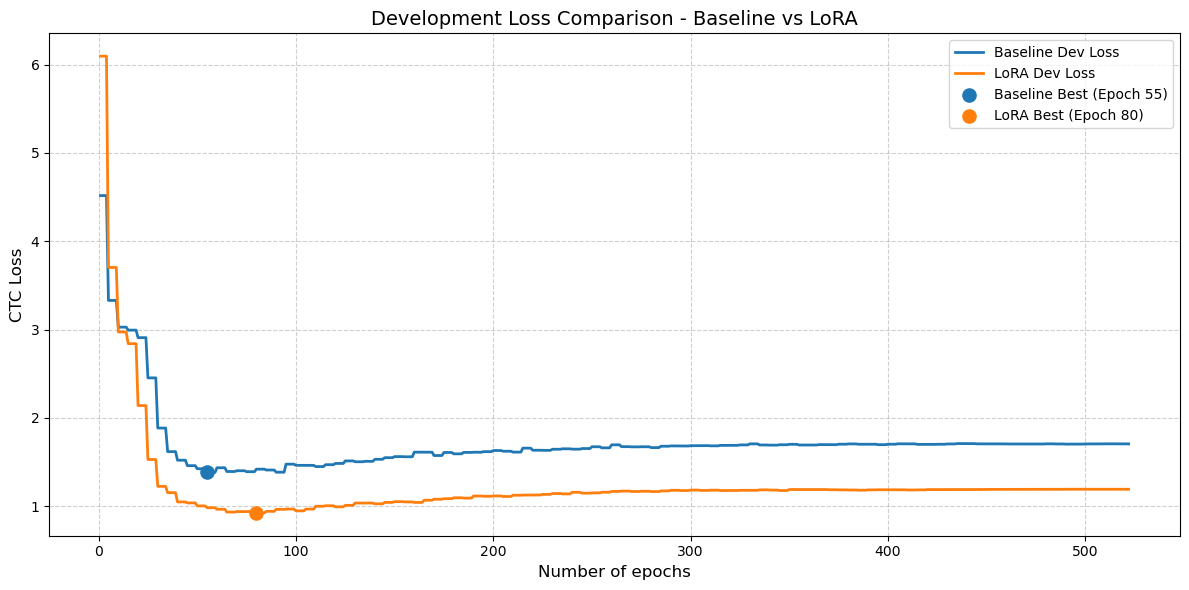

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(baseline_epochs, baseline_dev_loss, label="Baseline Dev Loss", lw=2)
plt.plot(lora_epochs, lora_dev_loss, label="LoRA Dev Loss", lw=2)

plt.scatter(
    baseline_best_epoch,
    baseline_best_loss,
    s=90,
    zorder=5,
    label=f"Baseline Best (Epoch {baseline_best_epoch})",
)

plt.scatter(
    lora_best_epoch,
    lora_best_loss,
    s=90,
    zorder=5,
    label=f"LoRA Best (Epoch {lora_best_epoch})",
)

plt.title("Development Loss Comparison - Baseline vs LoRA", fontsize=14)
plt.xlabel("Number of epochs", fontsize=12)
plt.ylabel("CTC Loss", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
baseline_state_dict = baseline_ckpt["model_state_dict"]
lora_state_dict = lora_ckpt["model_state_dict"]

baseline_weight_key = [k for k in baseline_state_dict.keys() if "weights" in k][0]
lora_weight_key = [k for k in lora_state_dict.keys() if "weights" in k][0]

baseline_raw_weights = baseline_state_dict[baseline_weight_key]
lora_raw_weights = lora_state_dict[lora_weight_key]

print("Baseline weight key:", baseline_weight_key)
print("LoRA weight key:", lora_weight_key)

Baseline weight key: weighted_sum.weights
LoRA weight key: weighted_sum.weights


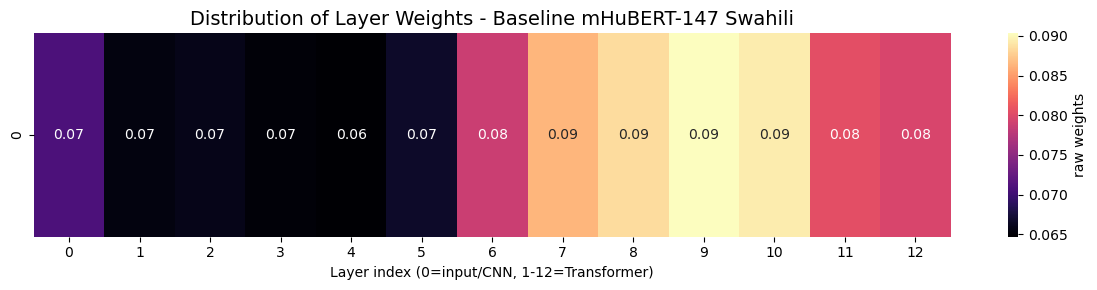

In [10]:
baseline_weight_matrix = baseline_raw_weights.reshape(1, -1)

plt.figure(figsize=(12, 3))
sns.heatmap(
    baseline_weight_matrix,
    annot=True,
    fmt=".2f",
    cmap="magma",
    xticklabels=range(baseline_weight_matrix.shape[1]),
    cbar_kws={"label": "raw weights"},
)

plt.title("Distribution of Layer Weights - Baseline mHuBERT-147 Swahili", fontsize=14)
plt.xlabel("Layer index (0=input/CNN, 1-12=Transformer)")
plt.tight_layout()
plt.show()

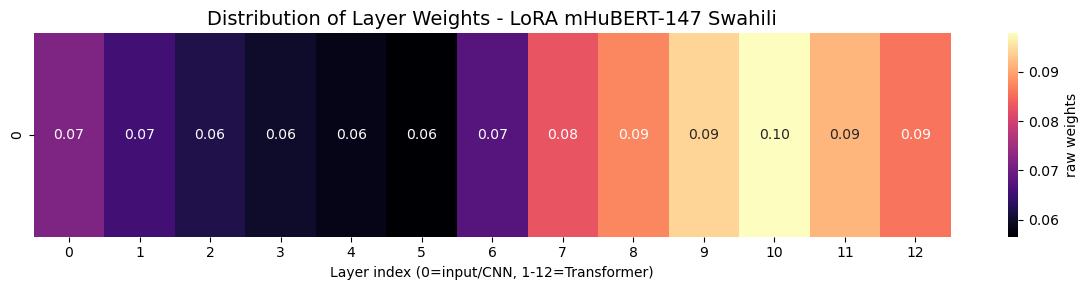

In [11]:
lora_weight_matrix = lora_raw_weights.reshape(1, -1)

plt.figure(figsize=(12, 3))
sns.heatmap(
    lora_weight_matrix,
    annot=True,
    fmt=".2f",
    cmap="magma",
    xticklabels=range(lora_weight_matrix.shape[1]),
    cbar_kws={"label": "raw weights"},
)

plt.title("Distribution of Layer Weights - LoRA mHuBERT-147 Swahili", fontsize=14)
plt.xlabel("Layer index (0=input/CNN, 1-12=Transformer)")
plt.tight_layout()
plt.show()

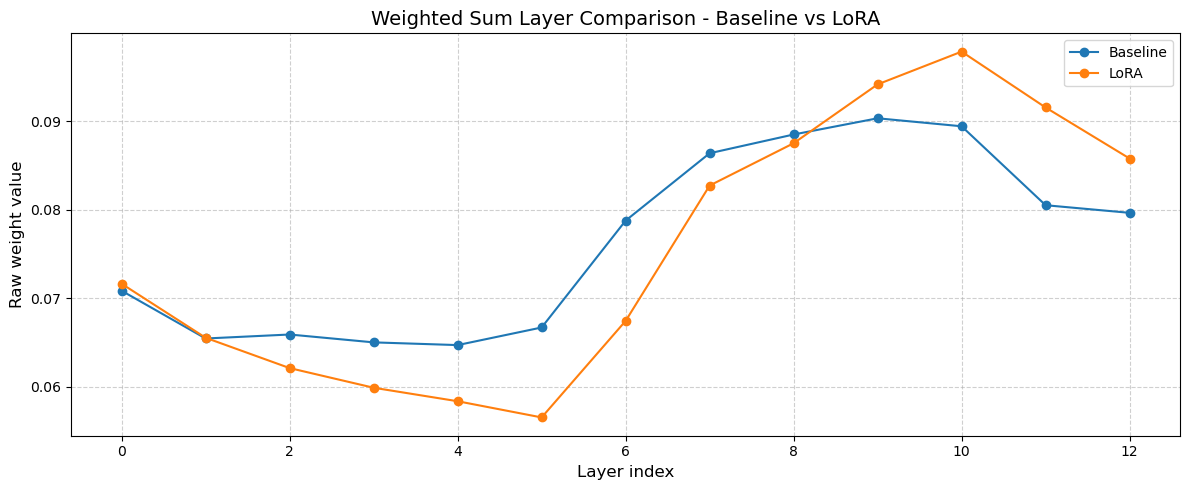

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(
    np.arange(len(baseline_raw_weights)),
    baseline_raw_weights.numpy(),
    marker="o",
    label="Baseline",
)
plt.plot(
    np.arange(len(lora_raw_weights)),
    lora_raw_weights.numpy(),
    marker="o",
    label="LoRA",
)

plt.title("Weighted Sum Layer Comparison - Baseline vs LoRA", fontsize=14)
plt.xlabel("Layer index", fontsize=12)
plt.ylabel("Raw weight value", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()